In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
from scipy.stats import ks_2samp
from scipy.special import entr

We will look at the eigenvalues stemming from two different randomizations: a simple shuffling of species abundances across samples, and the more complex switching method that accounts for total sample biomass (named MCMC).

We will compare both distribution with the KS test to check whether they are compatible or not.

In [2]:
dataset_name = 'Grilli.Soil'


with open('../../datasets/dummy_datasets_MCMC/dummy_eigvals.MCMC.{}.dat'.format(dataset_name),'rb') as f:
    MCMC_eigvals = pickle.load(f)
    f.close()

with open('../../datasets/dummy_eigvals_basic_shuffling/random_eigvals.{}.dat'.format(dataset_name),'rb') as f:
    basic_shuffling_eigvals = pickle.load(f)
    f.close()

MCMC_eigvals = np.array(MCMC_eigvals)
basic_shuffling_eigvals = np.array(basic_shuffling_eigvals)

C:\Users\Lenovo\anaconda3\lib\site-packages\numpy\lib\histograms.py:839: ComplexWarning: Casting complex values to real discards the imaginary part
  indices = f_indices.astype(np.intp)
C:\Users\Lenovo\anaconda3\lib\site-packages\numpy\lib\histograms.py:882: ComplexWarning: Casting complex values to real discards the imaginary part
  db = np.array(np.diff(bin_edges), float)
C:\Users\Lenovo\anaconda3\lib\site-packages\matplotlib\collections.py:192: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)
C:\Users\Lenovo\anaconda3\lib\site-packages\matplotlib\transforms.py:762: ComplexWarning: Casting complex values to real discards the imaginary part
  points = np.asarray(points, float)


Text(0, 0.5, 'Distribution')

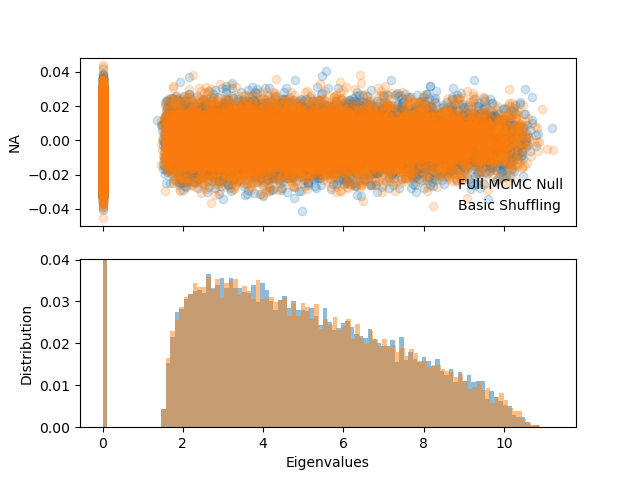

In [3]:
%matplotlib widget

MCMC_counts,MCMC_bins = np.histogram(MCMC_eigvals,density=True,bins=100)
MCMC_dbin = MCMC_bins[1]-MCMC_bins[0]
MCMC_bin_centers = MCMC_bins[:-1]+MCMC_dbin/2

basic_shuffling_counts,shuffling_bins = np.histogram(basic_shuffling_eigvals,density=True,bins=100)
shuffling_dbin = shuffling_bins[1]-shuffling_bins[0]
shuffling_bin_centers = shuffling_bins[:-1]+shuffling_dbin/2

fig,ax = plt.subplots(2,1,sharex=True)
ax[0].scatter(MCMC_eigvals,
           np.zeros(len(MCMC_eigvals))+np.random.normal(0,0.01,size=len(MCMC_eigvals)),
          label='FUll MCMC Null',#edgecolor='k',
           alpha=0.2)
ax[0].scatter(basic_shuffling_eigvals,
           np.zeros(len(basic_shuffling_eigvals))+np.random.normal(0,0.01,size=len(basic_shuffling_eigvals)),
          label='Basic Shuffling',#edgecolor='k',
           alpha=0.2)
ax[0].legend(loc='best',frameon=False)
ax[0].set_ylabel('NA')
# ax[0].set_xscale('log')
ax[1].bar(MCMC_bin_centers,MCMC_counts,
         width=MCMC_dbin,
          alpha=0.5)
ax[1].bar(shuffling_bin_centers,basic_shuffling_counts,
         width=shuffling_dbin,
          alpha=0.5)
ax[1].set_ylim(top=1.1*np.max((MCMC_counts[1:],basic_shuffling_counts[1:])))
ax[1].set_xlabel('Eigenvalues')
ax[1].set_ylabel('Distribution')


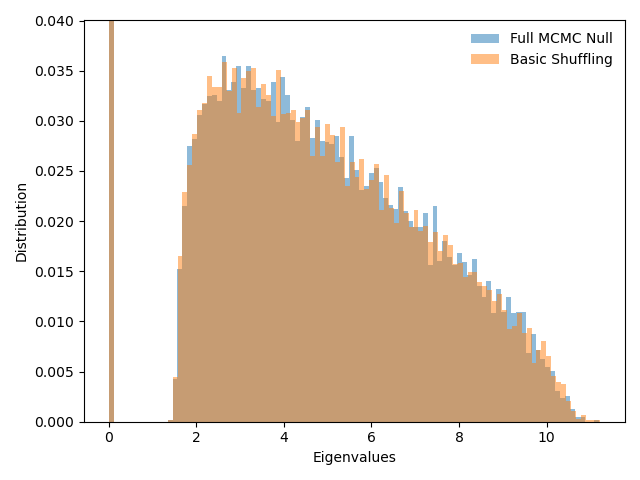

In [4]:
%matplotlib widget

MCMC_counts,MCMC_bins = np.histogram(MCMC_eigvals,density=True,bins=100)
MCMC_dbin = MCMC_bins[1]-MCMC_bins[0]
MCMC_bin_centers = MCMC_bins[:-1]+MCMC_dbin/2

basic_shuffling_counts,shuffling_bins = np.histogram(basic_shuffling_eigvals,density=True,bins=100)
shuffling_dbin = shuffling_bins[1]-shuffling_bins[0]
shuffling_bin_centers = shuffling_bins[:-1]+shuffling_dbin/2

fig,ax = plt.subplots(1,1,sharex=True)
ax.bar(MCMC_bin_centers,MCMC_counts,
         width=MCMC_dbin,label = 'Full MCMC Null',
          alpha=0.5)
ax.bar(shuffling_bin_centers,basic_shuffling_counts,
         width=shuffling_dbin,label='Basic Shuffling',
          alpha=0.5)
ax.set_ylim(top=1.1*np.max((MCMC_counts[1:],basic_shuffling_counts[1:])))
ax.set_xlabel('Eigenvalues')
ax.set_ylabel('Distribution')
ax.legend(loc='best',frameon=False)
plt.tight_layout()
plt.savefig('MCMC_vs_basic_null_distributions.{}.png'.format(dataset_name),format='png')


In [5]:
''' Run two-sided KS test '''

# KS_res = ks_2samp(MCMC_eigvals[(MCMC_eigvals>1e-1) & (MCMC_eigvals<1.8)],basic_shuffling_eigvals) #Considers only bulk eigenvalues in the Estrella Dataset
KS_res = ks_2samp(MCMC_eigvals,basic_shuffling_eigvals)
print(KS_res)


KstestResult(statistic=0.003529411764705892, pvalue=0.8745646875892402, statistic_location=(1.1492554414404668e-15+0j), statistic_sign=-1)
